In [1]:
# imports
%pip install seaborn -qq
%pip install grad-cam -qq

import medmnist
import os
import torch
import numpy as np
import torch.nn as nn
import seaborn as sns
import matplotlib.pyplot as plt
from medmnist import BloodMNIST
import torchvision.models as models
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# check if we have CUDA acceleration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"using: {device}")

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
using: cuda


# Transforms

In [2]:
"""
Image transformation pipelines for model training and evaluation.
- train_transforms: Applies random augmentations (flips, rotation, color jitter) to improve model generalization.
- test_transforms: Standardizes validation/test data (tensor conversion, ImageNet normalization) without altering the image.
"""

# image data augmentation for training
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(25),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # ImageNet normalization values
])

# no augmentation for val or test
test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # ImageNet normalization values
])

# Load Datasets

In [3]:
"""
Directory configuration and dataset initialization.
- Sets file paths for the BloodMNIST data and output figures.
- Loads the train, validation, and test splits, applying the appropriate transformation pipelines.
"""

# change the data_folder path if needed
data_folder = "/blue/bme6938/gael.garcia/bme6938-project-2/data"
figures_folder = "/blue/bme6938/gael.garcia/bme6938-project-2/figures"
models_folder = "/blue/bme6938/gael.garcia/bme6938-project-2/models"

# reload the data with the transforms applied
train_dataset = BloodMNIST(split='train', download=False, size=224, root=data_folder, transform=train_transforms)
val_dataset   = BloodMNIST(split='val',   download=False, size=224, root=data_folder, transform=test_transforms)
test_dataset  = BloodMNIST(split='test',  download=False, size=224, root=data_folder, transform=test_transforms)

print(f"Training dataset length: {len(train_dataset)}")
print(f"Training dataset length: {len(val_dataset)}")
print(f"Training dataset length: {len(test_dataset)}")

Training dataset length: 11959
Training dataset length: 1712
Training dataset length: 3421


# DataLoaders

In [4]:
"""
Data iterators to handle batching during the training loop.
- train_loader: Batches the data (size 64) and shuffles to ensure random sampling during gradient updates.
- val_loader & test_loader: Batches the data sequentially (no shuffling) for consistent metric evaluation.
"""

# define our dataloaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False) # note that we DONT shuffle for validation and test loaders
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Model 1: Custom CNN (from scratch)

In [5]:
"""
Custom Convolutional Neural Network (CNN) architecture.
- Features: 4 sequential convolutional blocks (Conv2d, BatchNorm, ReLU, MaxPool) to progressively extract image features.
- Classifier: Uses global average pooling, dense layers, and dropout to map the extracted features to the 8 output classes.
"""

# create a custom CNN from scratch
class CustomCNN(nn.Module):
    def __init__(self, num_classes=8):
        super(CustomCNN, self).__init__()
        
        # extract image features
        # sequential allows us to define multiple layers sequentially (one after the other)
        self.features = nn.Sequential(
        
            # block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),                         # activation function
            nn.MaxPool2d(2, 2),

            # block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),                         # activation function
            nn.MaxPool2d(2, 2),

            # block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),                         # activation function
            nn.MaxPool2d(2, 2),

            # block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),                         # activation function
            nn.MaxPool2d(2, 2),
        
        )
        
        # preform classification
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten(),                      # convert to 1D vector
            nn.Linear(256, 128),
            nn.ReLU(),                         # activation function
            nn.Dropout(0.5),                   # dropout helps prevent overfitting
            nn.Linear(128, num_classes),       # want the output to be limited to number of classes we have
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x
    
model = CustomCNN().to(device)
print(model)

CustomCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)

### Sanity Check

In [19]:
"""
Sanity Check: Pass a dummy batch through the model to verify output dimensions
Input: [4, 3, 64, 64] -> (Batch Size, RGB Channels, Height, Width)
Expected Output: [4, 8] -> (Batch Size, Number of Classes)
"""

with torch.no_grad():
    dummy = torch.rand(4, 3, 224, 224).to(device)
    out = model(dummy)
    print(f"Shape: {out.shape}")

Shape: torch.Size([4, 8])


# Loss + Optimizer

In [7]:
"""
Training configuration setup.
- criterion: Uses Cross-Entropy to calculate the error for our multi-class classification.
- optimizer: Uses Adam to update the model's weights based on the computed gradients.
- scheduler: Dynamically drops the learning rate if the validation loss plateaus to help the model converge.
"""

criterion = nn.CrossEntropyLoss() # this is our loss function that penalizes the model during training - internally applies Softmax
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3) # Adam is the adpative optimizer that adjust learning rates

# learning rate scheduler: reduces the LR when validation loss stops improving.
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5) 

# Training Loop

In [8]:
"""
Complete training loop for the PyTorch model.
- Handles both training (gradient updates) and validation (evaluation) phases per epoch.
- Implements early stopping to prevent overfitting and saves the best model weights.
- Tracks and returns loss and accuracy metrics for both phases across all epochs.
"""

# create a function used for training a provided model
def train_model(model, train_loader, val_loader, model_name, num_epochs=50, patience=5):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

    best_val_loss = float('inf')
    epochs_no_improve = 0
    train_losses, val_losses, train_accs, val_accs = [], [], [], [] # track metrics for plotting later

    for epoch in range(num_epochs):
        # --- training ---
        model.train()                                       # set model to training mode (enables dropout)
        running_loss, correct, total = 0, 0, 0
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.squeeze().long().to(device)

            optimizer.zero_grad()                           # clear old gradients from the last step
            outputs = model(images)                         # forward pass
            loss = criterion(outputs, labels)               # compute error
            loss.backward()                                 # compute gradients (backpropagation)
            optimizer.step()                                # update model weights

            running_loss += loss.item()
            _, predicted = outputs.max(1)                   # get the index of the max log-probability
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc  = correct / total

        # --- validation ---
        model.eval()                                        # set model to evaluation mode (disables dropout)
        val_loss, correct, total = 0, 0, 0
        with torch.no_grad():                               # disable gradient calculation to save memory/compute
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.squeeze().long().to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = outputs.max(1)
                correct += predicted.eq(labels).sum().item()
                total += labels.size(0)

        val_loss = val_loss / len(val_loader)
        val_acc  = correct / total

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        scheduler.step(val_loss)                            # adjust learning rate based on validation loss

        # --- early stopping + save best ---
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), os.path.join(models_folder, f"best_{model_name}.pth")) # save the best preforming weights
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:                        # stop early if validation loss hasnt improved
                print(f"early stopping triggered at epoch {epoch+1}")
                break

        print(f"[{model_name}] epoch {epoch+1:02d}/{num_epochs} | train loss: {train_loss:.4f} acc: {train_acc:.4f} | val loss: {val_loss:.4f} acc: {val_acc:.4f}")

    print(f"{model_name} done!")
    return train_losses, val_losses, train_accs, val_accs

In [9]:
print("=== training scratch CNN ===")

# training for max 50 epochs,, 50 was defined in the function, no need to include it again
cnn_results = train_model(model, train_loader, val_loader, "cnn")

=== training scratch CNN ===
[cnn] epoch 01/50 | train loss: 1.2325 acc: 0.5537 | val loss: 0.6605 acc: 0.7424
[cnn] epoch 02/50 | train loss: 0.7600 acc: 0.7169 | val loss: 0.6015 acc: 0.8026
[cnn] epoch 03/50 | train loss: 0.6067 acc: 0.7821 | val loss: 0.6278 acc: 0.7529
[cnn] epoch 04/50 | train loss: 0.5327 acc: 0.8102 | val loss: 0.3831 acc: 0.8581
[cnn] epoch 05/50 | train loss: 0.4438 acc: 0.8451 | val loss: 0.6558 acc: 0.7494
[cnn] epoch 06/50 | train loss: 0.4208 acc: 0.8560 | val loss: 0.3630 acc: 0.8499
[cnn] epoch 07/50 | train loss: 0.4005 acc: 0.8611 | val loss: 0.2635 acc: 0.9118
[cnn] epoch 08/50 | train loss: 0.3646 acc: 0.8776 | val loss: 0.2020 acc: 0.9276
[cnn] epoch 09/50 | train loss: 0.3600 acc: 0.8805 | val loss: 0.3349 acc: 0.8727
[cnn] epoch 10/50 | train loss: 0.3232 acc: 0.8883 | val loss: 0.5569 acc: 0.8055
[cnn] epoch 11/50 | train loss: 0.3246 acc: 0.8927 | val loss: 0.1809 acc: 0.9451
[cnn] epoch 12/50 | train loss: 0.2967 acc: 0.9054 | val loss: 0.1452

# Training Curve Plot 

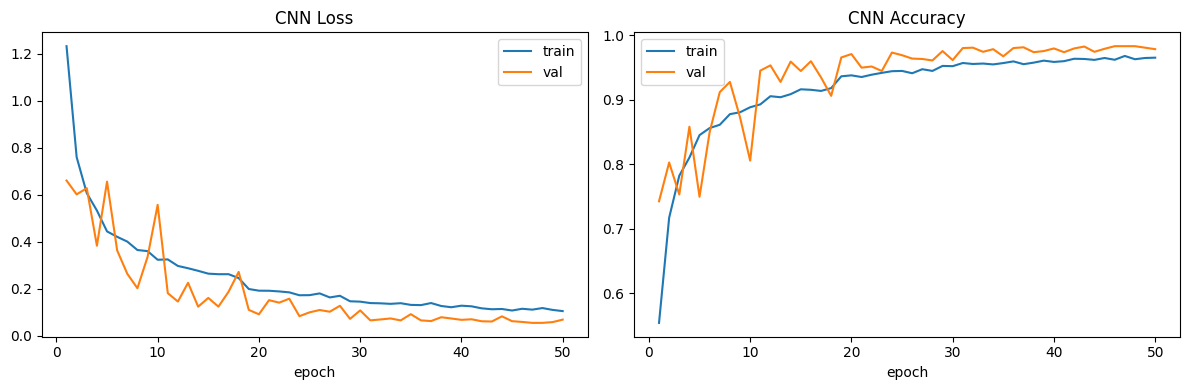

In [18]:
"""
Visualization of the training and validation metrics for the CNN trained from scratch.
- Unpacks the results from the training loop.
- Generates a side-by-side plot of Loss and Accuracy across epochs.
- Saves the generated figure to the designated figures folder.
"""

# unpack the results returned from the train_model function
cnn_train_losses, cnn_val_losses, cnn_train_accs, cnn_val_accs = cnn_results

epochs_ran = range(1, len(cnn_train_losses) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# plot 1: loss
ax1.plot(epochs_ran, cnn_train_losses, label='train')
ax1.plot(epochs_ran, cnn_val_losses, label='val')
ax1.set_title('CNN Loss')
ax1.set_xlabel('epoch')
ax1.legend()

# plot 2: accuracy
ax2.plot(epochs_ran, cnn_train_accs, label='train')
ax2.plot(epochs_ran, cnn_val_accs, label='val')
ax2.set_title('CNN Accuracy')
ax2.set_xlabel('epoch')
ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join(figures_folder, 'cnn_training_curve.png'), dpi=150)
plt.show()

# Pretrained Models (ResNet and EfficientNet)

In [11]:
"""
Pre-trained model initialization for Transfer Learning.
- Loads ResNet50 and EfficientNet-B0 architectures with standard ImageNet weights.
- Replaces the final classification layers to output our specific 8 classes instead of the default 1000.
"""

# load pretrained ResNet50 model
def get_resnet50(num_classes=8):
    model = models.resnet50(weights='IMAGENET1K_V1')
    
    # swap the final fully connected (fc) layer to output 8 classes
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

# load pretrained EfficientNet-B0 model
def get_efficientnet(num_classes=8):
    model = models.efficientnet_b0(weights='IMAGENET1K_V1')
    
    # swap the final linear layer in the classifier block
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    return model

resnet_model = get_resnet50().to(device)
efficientnet_model = get_efficientnet().to(device)

print("resnet50 ready")
print("efficientnet_b0 ready")

resnet50 ready
efficientnet_b0 ready


In [12]:
print("\n=== training resnet50 ===")
# training for max 50 epochs,, 50 was defined in the function, no need to include it again
resnet_results = train_model(resnet_model, train_loader, val_loader, "resnet50")

print("\n=== training efficientnet ===")
# training for max 50 epochs,, 50 was defined in the function, no need to include it again
efficientnet_results = train_model(efficientnet_model, train_loader, val_loader, "efficientnet")


=== training resnet50 ===
[resnet50] epoch 01/50 | train loss: 0.3344 acc: 0.8881 | val loss: 1.8177 acc: 0.5970
[resnet50] epoch 02/50 | train loss: 0.2054 acc: 0.9304 | val loss: 0.3965 acc: 0.8598
[resnet50] epoch 03/50 | train loss: 0.1475 acc: 0.9489 | val loss: 0.1533 acc: 0.9433
[resnet50] epoch 04/50 | train loss: 0.1312 acc: 0.9551 | val loss: 0.1403 acc: 0.9474
[resnet50] epoch 05/50 | train loss: 0.1018 acc: 0.9668 | val loss: 0.1391 acc: 0.9521
[resnet50] epoch 06/50 | train loss: 0.0914 acc: 0.9677 | val loss: 0.1660 acc: 0.9539
[resnet50] epoch 07/50 | train loss: 0.0943 acc: 0.9687 | val loss: 0.0890 acc: 0.9714
[resnet50] epoch 08/50 | train loss: 0.0843 acc: 0.9721 | val loss: 0.0890 acc: 0.9679
[resnet50] epoch 09/50 | train loss: 0.0758 acc: 0.9749 | val loss: 0.0594 acc: 0.9807
[resnet50] epoch 10/50 | train loss: 0.0734 acc: 0.9729 | val loss: 0.1135 acc: 0.9544
[resnet50] epoch 11/50 | train loss: 0.0792 acc: 0.9717 | val loss: 0.1620 acc: 0.9480
[resnet50] epoch

# Evalutation

In [13]:
"""
Model evaluation function for the test dataset.
- Disables gradient tracking to speed up inference and save memory.
- Iterates through the test data to collect predictions, true labels, and class probabilities.
- Outputs a detailed classification report and calculates the multi-class ROC-AUC score.
"""

def evaluate_model(model, test_loader, model_name):
    model.eval()                                                     # set to evaluation mode (disables dropout/batchnorm updates)
    all_preds, all_labels, all_probs = [], [], []
    
    with torch.no_grad():                                            # turn off gradients for evaluation
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.squeeze().long()
            outputs = model(images)                                  # forward pass
            
            # apply softmax to get probabilities (needed for ROC-AUC)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            _, predicted = outputs.max(1)                            # get final class prediction
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs)
    
    # convert lists to numpy arrays
    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)
    
    # classification report
    print(f"\n=== {model_name} test results ===")
    print(classification_report(all_labels, all_preds, digits=4))
    
    auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')
    print(f"ROC-AUC (macro ovr): {auc:.4f}")
    
    return all_preds, all_labels, all_probs

In [14]:
# evaluate all 3 models with classification report and ROC/AUC scores
cnn_preds, cnn_labels, cnn_probs           = evaluate_model(model, test_loader, "scratch CNN")
resnet_preds, resnet_labels, resnet_probs  = evaluate_model(resnet_model, test_loader, "resnet50")
eff_preds, eff_labels, eff_probs           = evaluate_model(efficientnet_model, test_loader, "efficientnet")


=== scratch CNN test results ===
              precision    recall  f1-score   support

           0     0.9382    0.9959    0.9662       244
           1     0.9984    1.0000    0.9992       624
           2     0.9967    0.9614    0.9787       311
           3     0.9404    0.9257    0.9330       579
           4     0.9567    1.0000    0.9779       243
           5     0.9887    0.9261    0.9564       284
           6     0.9586    0.9745    0.9665       666
           7     1.0000    1.0000    1.0000       470

    accuracy                         0.9725      3421
   macro avg     0.9722    0.9729    0.9722      3421
weighted avg     0.9728    0.9725    0.9724      3421

ROC-AUC (macro ovr): 0.9990

=== resnet50 test results ===
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       244
           1     0.9984    1.0000    0.9992       624
           2     0.9968    0.9904    0.9935       311
           3     0.9827    0.9810    0.

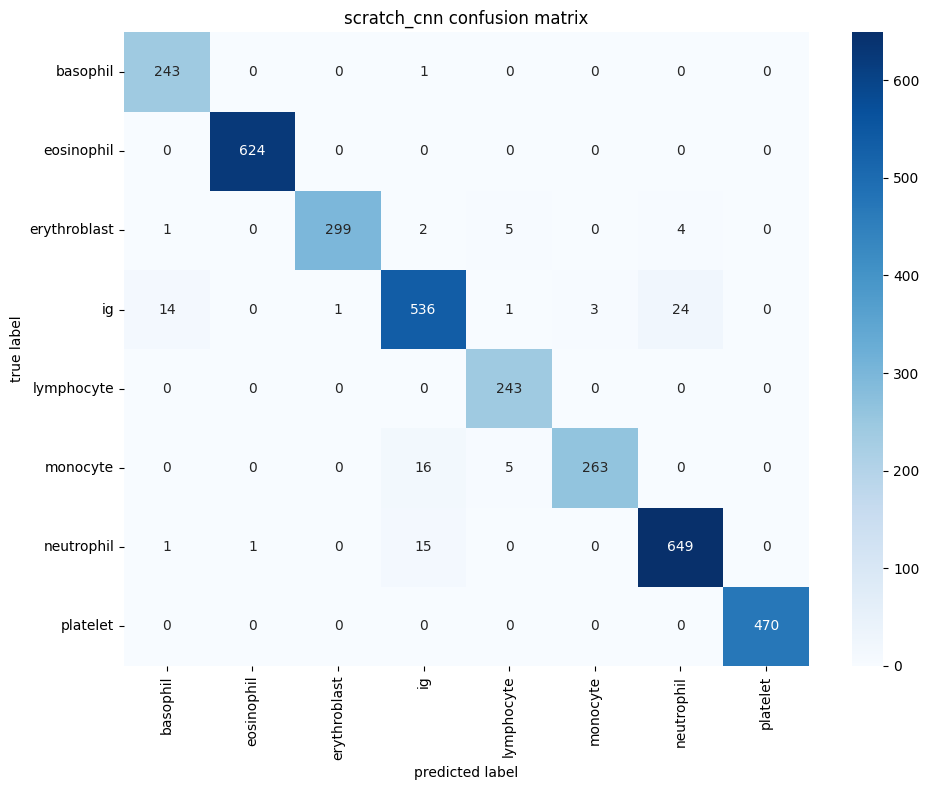

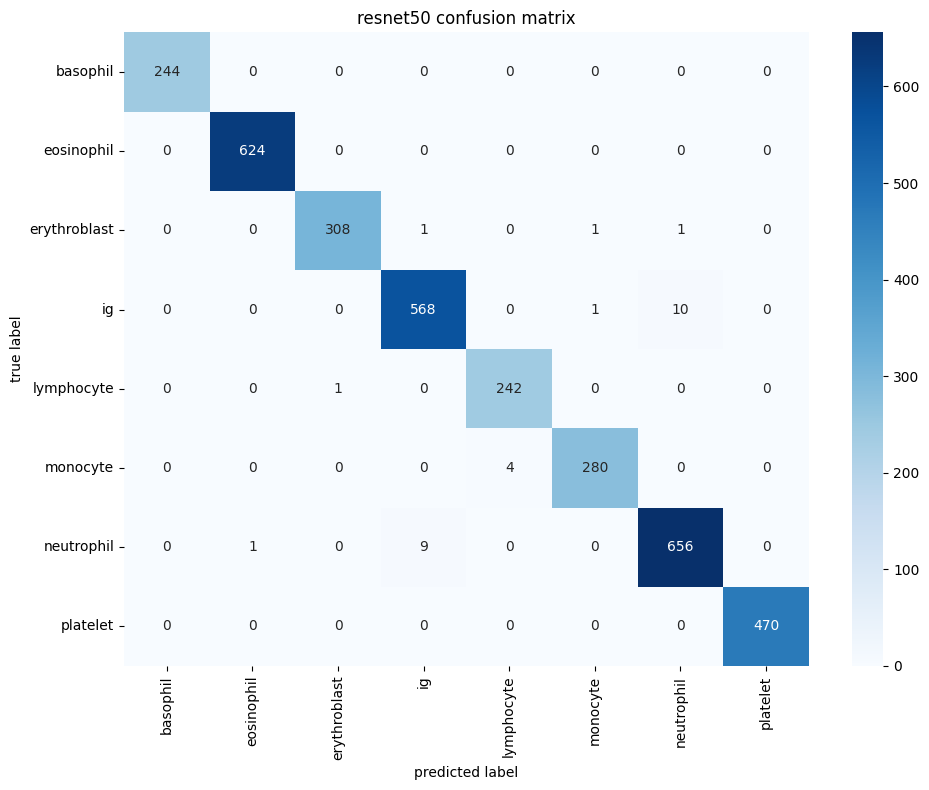

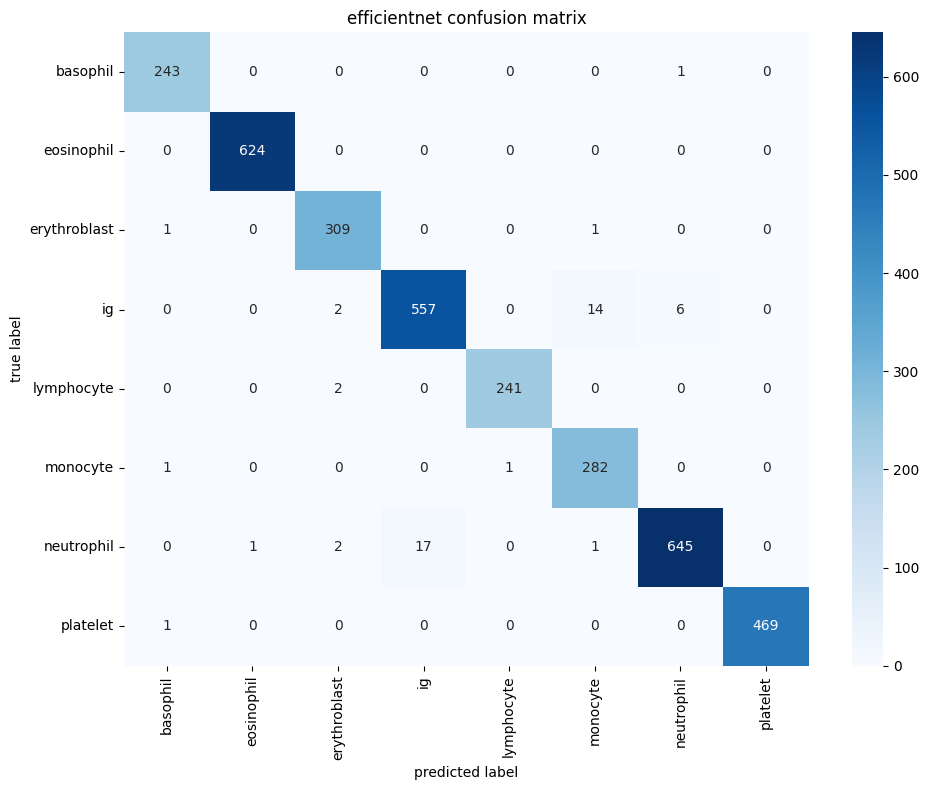

In [15]:
"""
Confusion matrix visualization for model comparison.
- Maps numerical predictions back to their specific blood cell string labels.
- Generates a color-coded heatmap (via seaborn) to easily spot which classes the models are confusing.
- Saves each generated matrix to the designated figures folder.
"""

# NOTE: ig = Immature granulocytes (myelocytes, metamyelocytes, and promyelocytes)

cell_types = ['basophil', 'eosinophil', 'erythroblast', 'ig', 'lymphocyte', 'monocyte', 'neutrophil', 'platelet']

# define a function to create the confusion matrix for said model
def plot_confusion_matrix(labels, preds, model_name):
    
    # calculate the raw counts of true vs predicted classifications
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=cell_types, yticklabels=cell_types)
    plt.title(f'{model_name} confusion matrix')
    plt.ylabel('true label')
    plt.xlabel('predicted label')
    plt.tight_layout()
    # save each plot as a png
    plt.savefig(os.path.join(figures_folder, f'confusion_matrix_{model_name}.png'), dpi=150)
    plt.show()
    
# create the confusion matrix for each of the 3 plots
plot_confusion_matrix(cnn_labels, cnn_preds, 'scratch_cnn')
plot_confusion_matrix(resnet_labels, resnet_preds, 'resnet50')
plot_confusion_matrix(eff_labels, eff_preds, 'efficientnet')

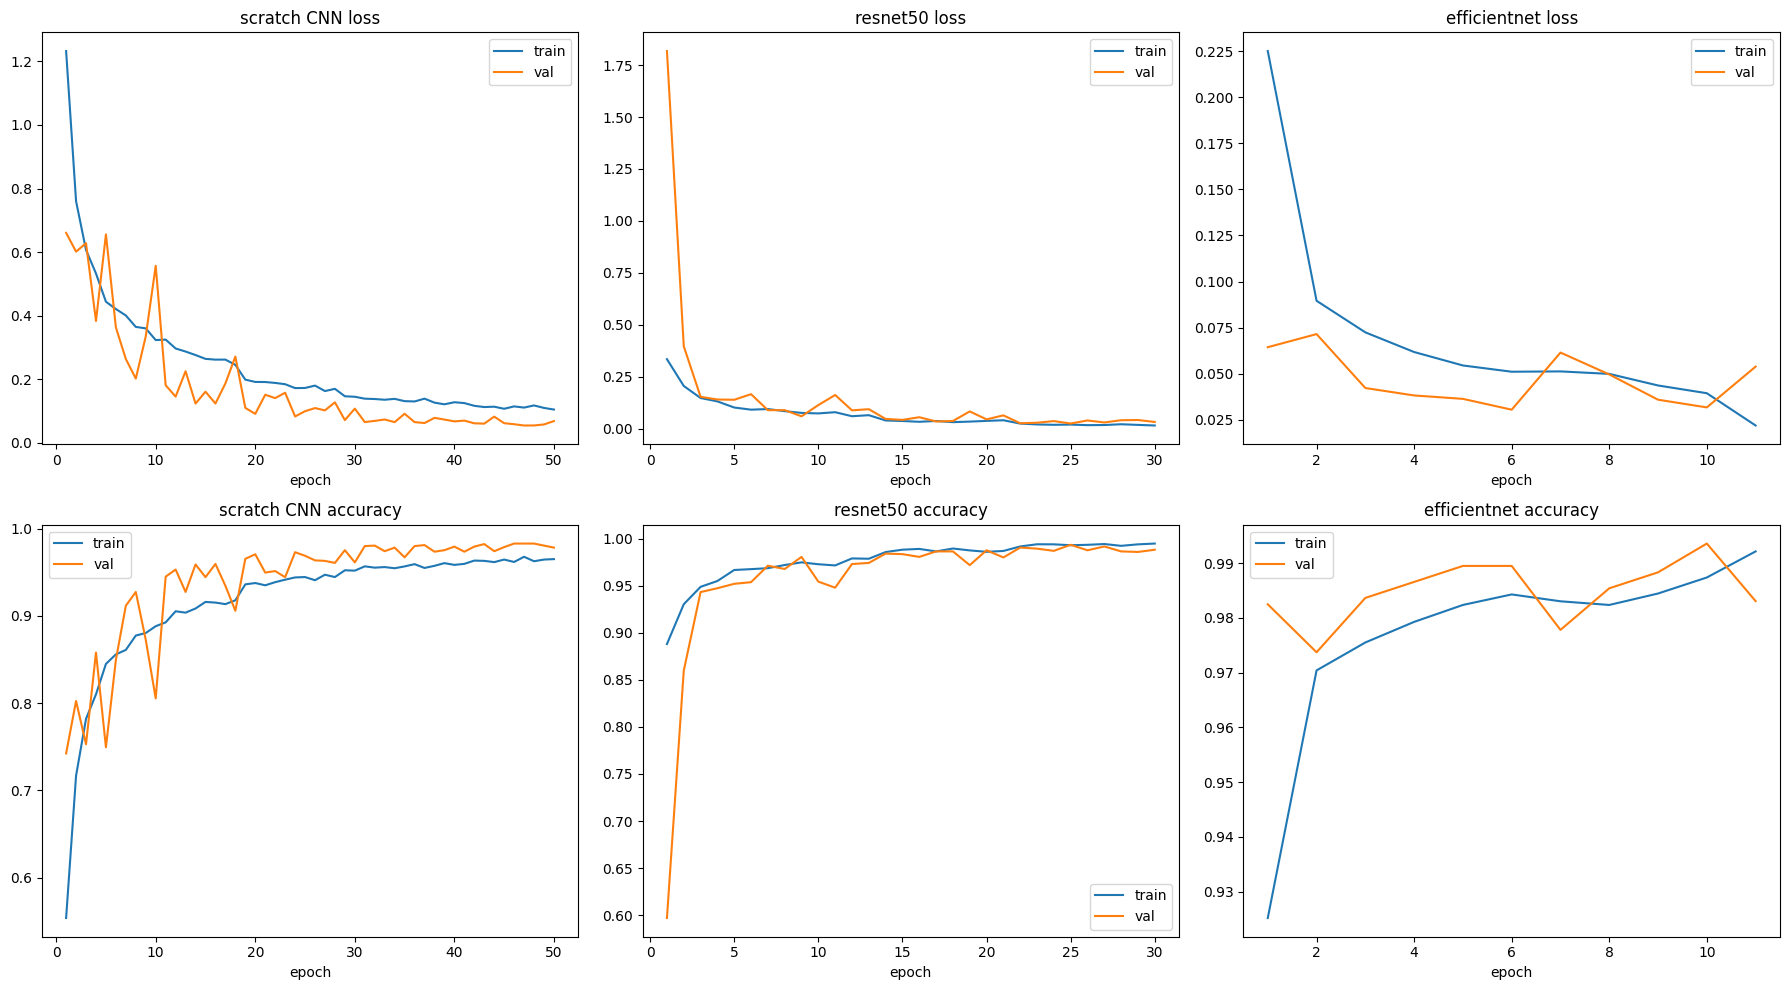

In [16]:
"""
Comprehensive training curve visualization.
- Aggregates the results from the Custom CNN, ResNet50, and EfficientNet.
- Generates a 2x3 subplot grid comparing the loss (top row) and accuracy (bottom row) of all three models side-by-side.
- Saves the final comparative figure to the designated figures folder.
"""

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# # bundle all results into a dictionary for clean iteration
results = {
    'scratch CNN': cnn_results,
    'resnet50': resnet_results,
    'efficientnet': efficientnet_results
}

for i, (name, (t_loss, v_loss, t_acc, v_acc)) in enumerate(results.items()):
    epochs = range(1, len(t_loss) + 1)
    
    # top row: loss
    axes[0, i].plot(epochs, t_loss, label='train')
    axes[0, i].plot(epochs, v_loss, label='val')
    axes[0, i].set_title(f'{name} loss')
    axes[0, i].set_xlabel('epoch')
    axes[0, i].legend()
    
    # bottom row: accuracy
    axes[1, i].plot(epochs, t_acc, label='train')
    axes[1, i].plot(epochs, v_acc, label='val')
    axes[1, i].set_title(f'{name} accuracy')
    axes[1, i].set_xlabel('epoch')
    axes[1, i].legend()

plt.tight_layout()
plt.savefig(os.path.join(figures_folder, f'all_models_training_curves.png'), dpi=150)
plt.show()

# Grad CAM Plots

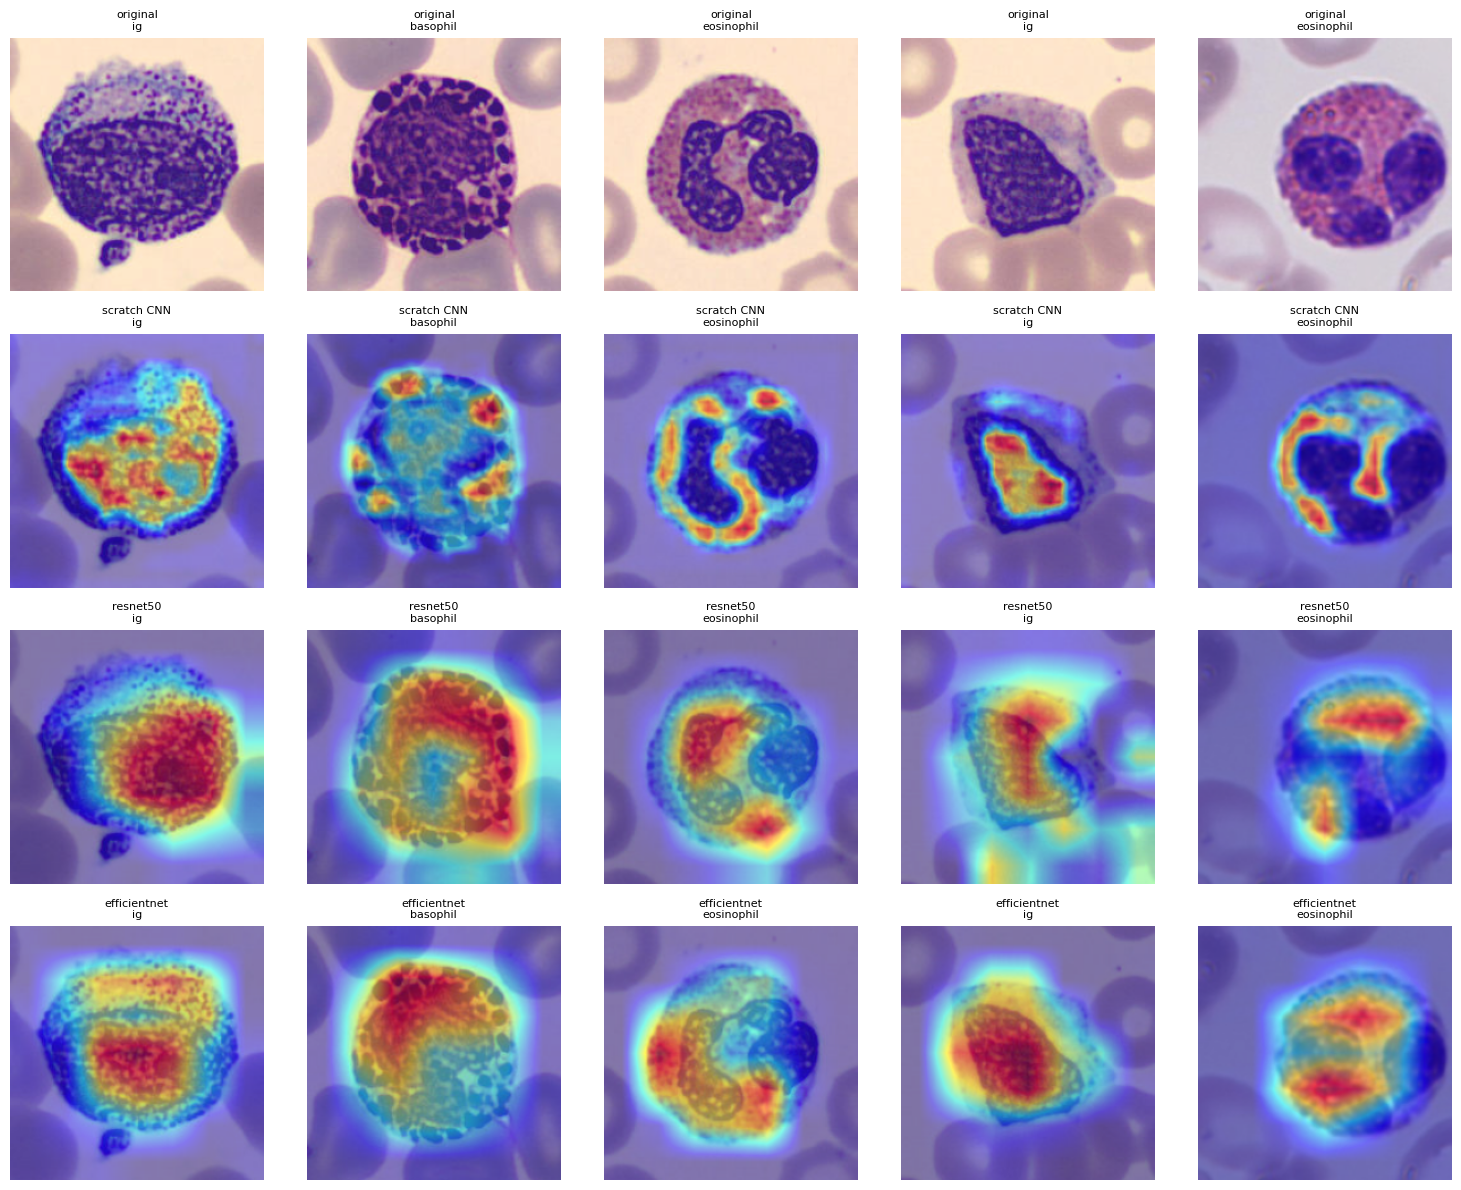

In [17]:
"""
Grad-CAM (Gradient-weighted Class Activation Mapping) visualizations.
- Initializes Grad-CAM for all three models by targeting their final convolutional layers.
- Un-normalizes a sample of test images to display them in standard RGB format.
- Generates a 4x5 grid comparing the original images against the heatmaps produced by each model, showing where they "look" to make predictions.
"""

# pick target layer for each model
cam_cnn = GradCAM(model=model, target_layers=[model.features[-2]])
cam_resnet = GradCAM(model=resnet_model, target_layers=[resnet_model.layer4[-1]])
cam_efficient = GradCAM(model=efficientnet_model, target_layers=[efficientnet_model.features[-1]])

# grab a few test images
sample_images, sample_labels = next(iter(test_loader))
sample_images = sample_images[:5].to(device)

fig, axes = plt.subplots(4, 5, figsize=(15, 12))

# row 0: original images
for j in range(5):
    img = sample_images[j].cpu().permute(1, 2, 0).numpy()
    img = img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
    img = np.clip(img, 0, 1)
    axes[0, j].imshow(img)
    axes[0, j].set_title(f'original\n{cell_types[sample_labels[j].item()]}', fontsize=8)
    axes[0, j].axis('off')

# rows 1-3: gradcam for each model
for i, (cam, name) in enumerate([(cam_cnn, 'scratch CNN'), (cam_resnet, 'resnet50'), (cam_efficient, 'efficientnet')]):
    grayscale_cams = cam(input_tensor=sample_images)
    for j in range(5):
        img = sample_images[j].cpu().permute(1, 2, 0).numpy()
        img = img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
        img = np.clip(img, 0, 1).astype(np.float32)
        cam_image = show_cam_on_image(img, grayscale_cams[j], use_rgb=True)
        axes[i+1, j].imshow(cam_image)
        axes[i+1, j].set_title(f'{name}\n{cell_types[sample_labels[j].item()]}', fontsize=8)
        axes[i+1, j].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(figures_folder, f'gradcam.png'), dpi=150)
plt.show()